In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [108]:
df = pd.read_csv('../dataset/insurance.csv')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [110]:
df.shape

(1338, 7)

In [161]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [112]:
sns.set(style ='whitegrid',palette ="Set2",font_scale = 1.2)

In [113]:
df.duplicated().sum()

np.int64(1)

In [114]:
df.drop_duplicates(inplace=True)

In [115]:
df.describe()

,age,bmi,children,charges
count,1337.0,1337.0,1337.0,1337.0
mean,39.2,30.7,1.1,13279.1
std,14.0,6.1,1.2,12110.4
min,18.0,16.0,0.0,1121.9
25%,27.0,26.3,0.0,4746.3
50%,39.0,30.4,1.0,9386.2
75%,51.0,34.7,2.0,16657.7
max,64.0,53.1,5.0,63770.4


In [116]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

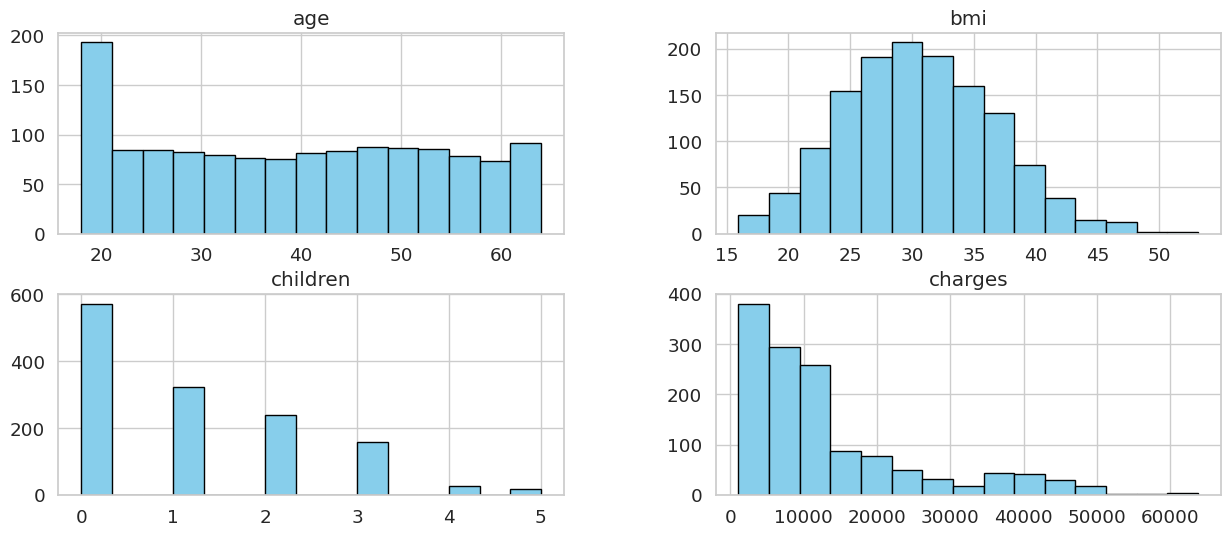

In [117]:
df[numeric_cols].hist(bins=15, figsize=(15, 6), color="skyblue", edgecolor="black", layout=(2, 2))

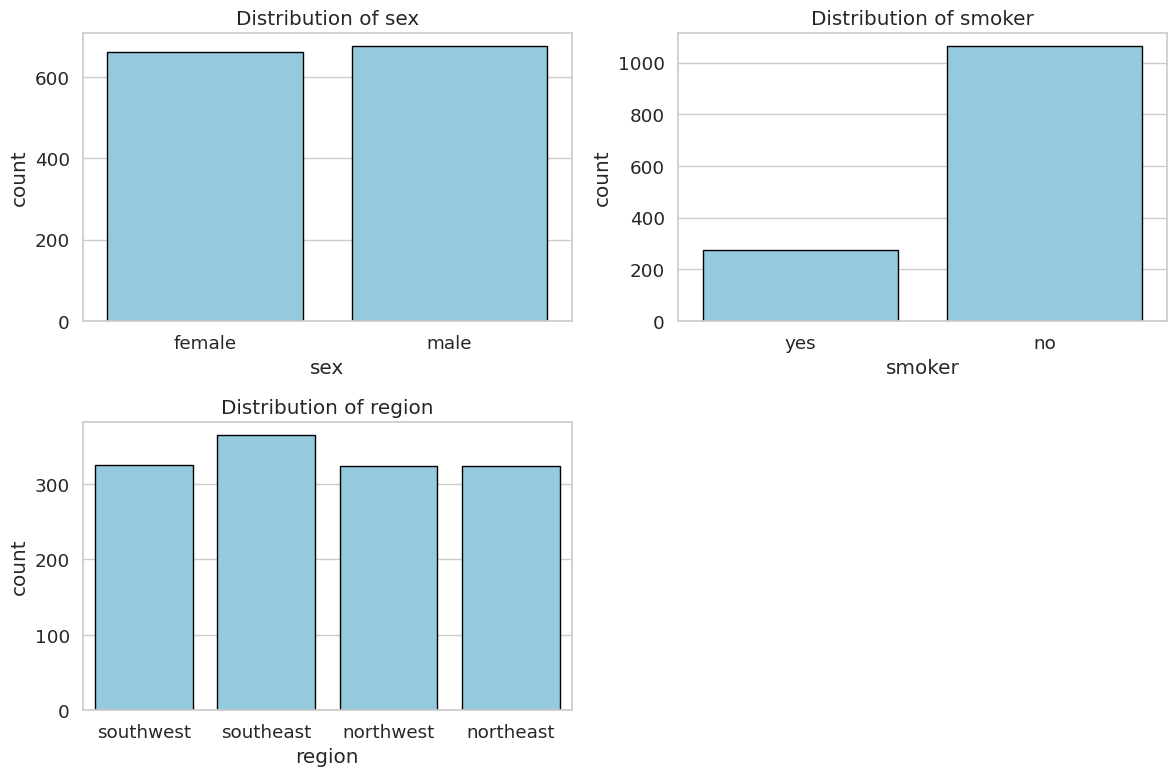

In [118]:
plt.figure(figsize=(12,8))

for i ,col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=df, x=col,color="skyblue",edgecolor="black")
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.tight_layout()
plt.show()

In [119]:
df.groupby(["sex","smoker"])["charges"].mean()

sex     smoker
female  no        8762.3
        yes      30679.0
male    no        8099.7
        yes      33042.0
Name: charges, dtype: float64

In [120]:
df.groupby(["region","smoker"])["charges"].mean()

region     smoker
northeast  no        9165.5
           yes      29673.5
northwest  no        8582.5
           yes      30192.0
southeast  no        8032.2
           yes      34845.0
southwest  no        8019.3
           yes      32269.1
Name: charges, dtype: float64

In [121]:
df.groupby(["sex","region"])["bmi"].mean()

sex     region   
female  northeast   29.3
        northwest   29.3
        southeast   32.7
        southwest   30.1
male    northeast   29.0
        northwest   29.1
        southeast   34.0
        southwest   31.1
Name: bmi, dtype: float64

In [122]:
df.groupby(["smoker","sex"])["charges"].count()

smoker  sex   
no      female    547
        male      516
yes     female    115
        male      159
Name: charges, dtype: int64

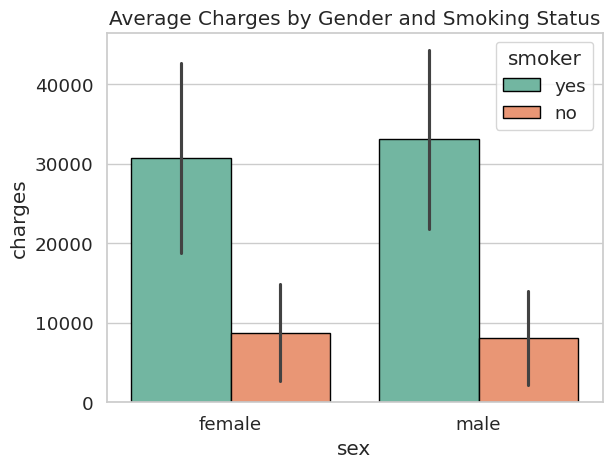

In [123]:
sns.barplot(data=df,x="sex",y="charges",hue="smoker",palette="Set2",edgecolor="black",estimator ="mean",errorbar='sd'
            ).set_title("Average Charges by Gender and Smoking Status")
plt.show()


In [124]:
pivot_region_smoker = df.groupby(["region","smoker"])["charges"].mean().unstack()

In [125]:
pivot_region_smoker

smoker,no,yes
region,,
northeast,9165.5,29673.5
northwest,8582.5,30192.0
southeast,8032.2,34845.0
southwest,8019.3,32269.1


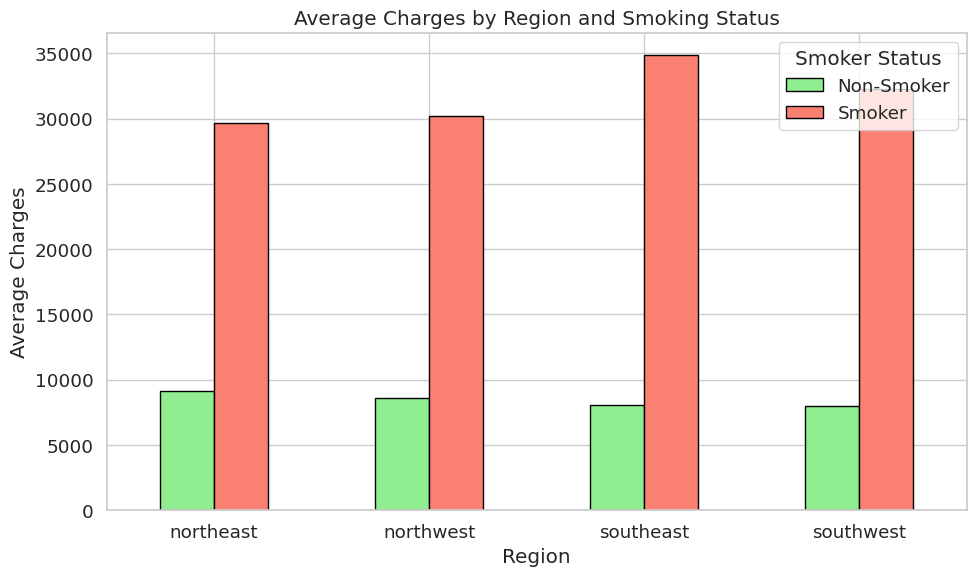

In [126]:
from pandas import pivot


pivot_region_smoker.plot(kind="bar", figsize=(10,6), color=["lightgreen","salmon"], edgecolor="black")
plt.title("Average Charges by Region and Smoking Status")
plt.ylabel("Average Charges")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.legend(title="Smoker Status", labels=["Non-Smoker", "Smoker"])
plt.tight_layout()
plt.show()

In [127]:
from pandas import pivot_table


pivot_table_region_smoker = pd.pivot_table(df, values="charges", index="region", columns="smoker", aggfunc=np.mean)
pivot_table_region_smoker

smoker,no,yes
region,,
northeast,9165.5,29673.5
northwest,8582.5,30192.0
southeast,8032.2,34845.0
southwest,8019.3,32269.1


In [128]:
pivot_table =pd.pivot_table(df, values="charges", index="children", columns ="smoker", aggfunc=np.mean)
pivot_table

smoker,no,yes
children,,
0,7624.8,31341.4
1,8303.1,31822.7
2,9493.1,33844.2
3,9614.5,32724.9
4,12121.3,26532.3
5,8183.8,19023.3


In [129]:
numeric_cols

['age', 'bmi', 'children', 'charges']

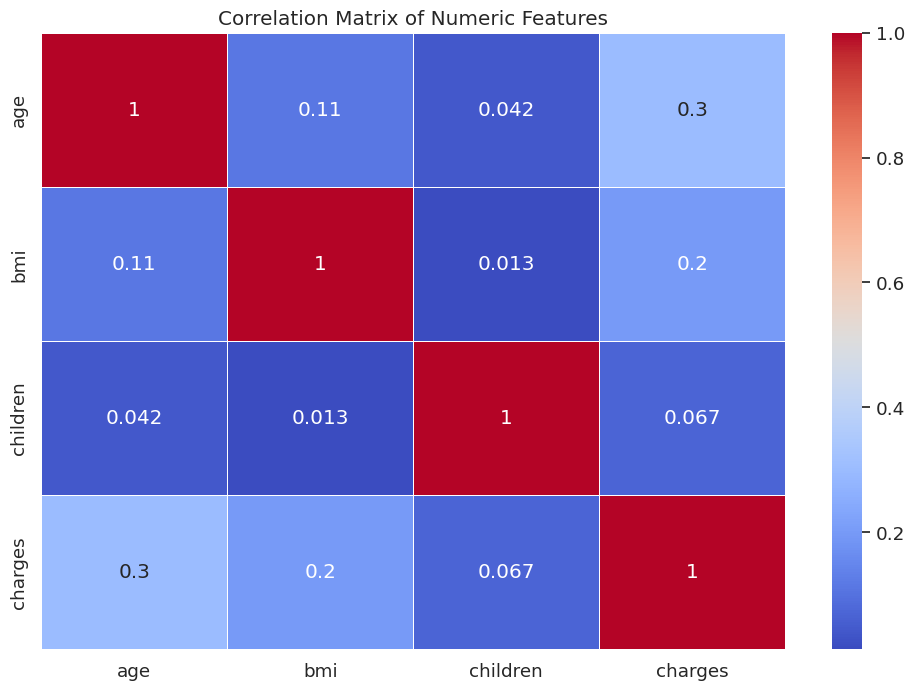

In [130]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

<Axes: xlabel='bmi', ylabel='charges'>

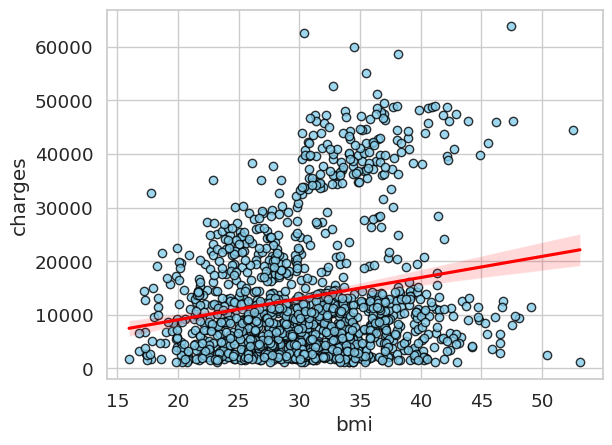

In [131]:
sns.regplot(data = df,x = "bmi", y = "charges", scatter_kws={"color":"skyblue","edgecolor":"black"}, line_kws={"color":"red"})

<Axes: xlabel='children', ylabel='charges'>

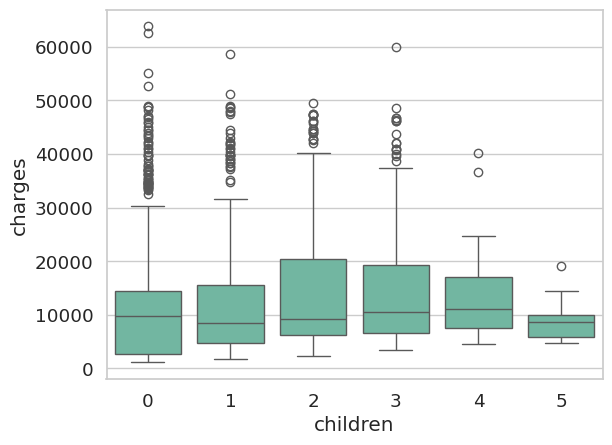

In [132]:
sns.boxplot(df,x="children",y="charges")

In [133]:
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65], labels=['18-24', '25-34', '35-44', '45-54', '55-64'])
df['age_group'].value_counts()

age_group
18-24    305
45-54    284
25-34    268
35-44    264
55-64    216
Name: count, dtype: int64

<Axes: xlabel='age_group', ylabel='charges'>

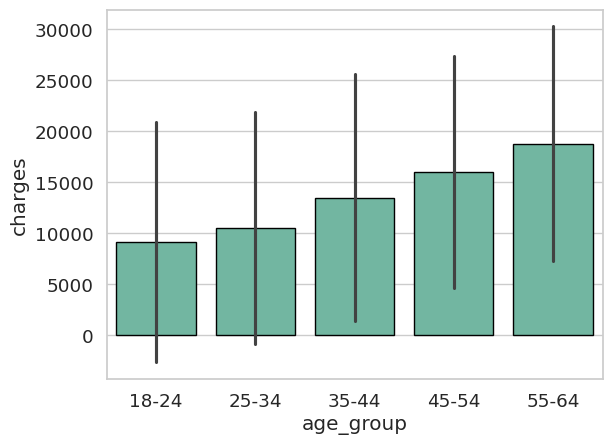

In [134]:
sns.barplot(data=df,x="age_group",y="charges",edgecolor="black",estimator ="mean",errorbar='sd')

In [135]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal weight", "Overweight", "Obesity"])
df["bmi_category"].value_counts()

bmi_category
Obesity          715
Overweight       380
Normal weight    221
Underweight       21
Name: count, dtype: int64

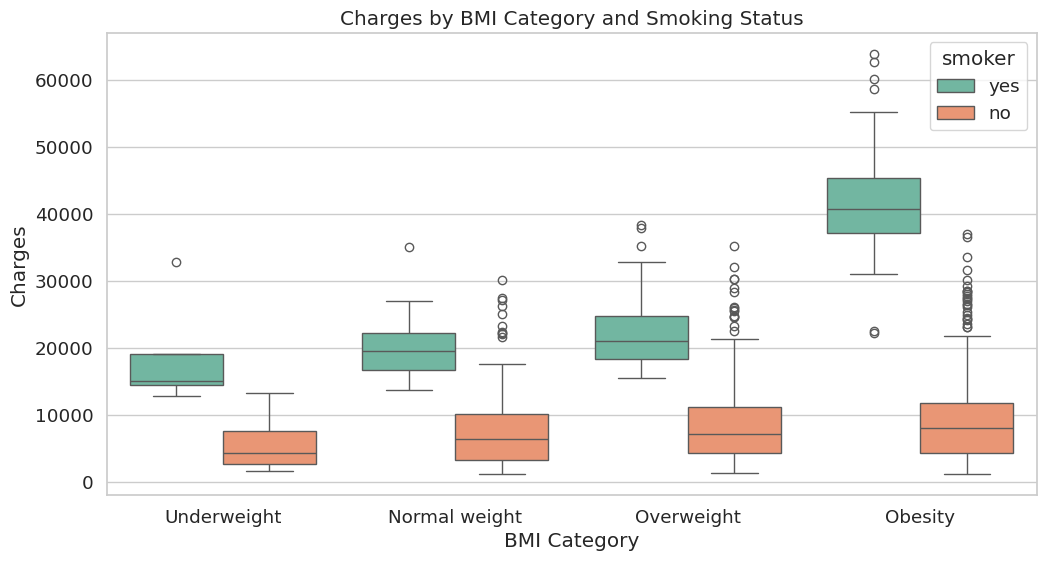

In [136]:
from matplotlib.pyplot import figure
plt.figure(figsize=(12,6))
sns.boxplot(df,x='bmi_category',y='charges',hue='smoker')
plt.title("Charges by BMI Category and Smoking Status")
plt.xlabel("BMI Category")
plt.ylabel("Charges")
plt.show()

## Feature Engineering

In [137]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x == "yes").mean() * 100),
    mean_charges = ("charges","mean")
).reset_index()



In [138]:
region_stats

,region,smoker_rate,mean_charges
0,northeast,20.7,13406.4
1,northwest,17.9,12450.8
2,southeast,25.0,14735.4
3,southwest,17.8,12346.9


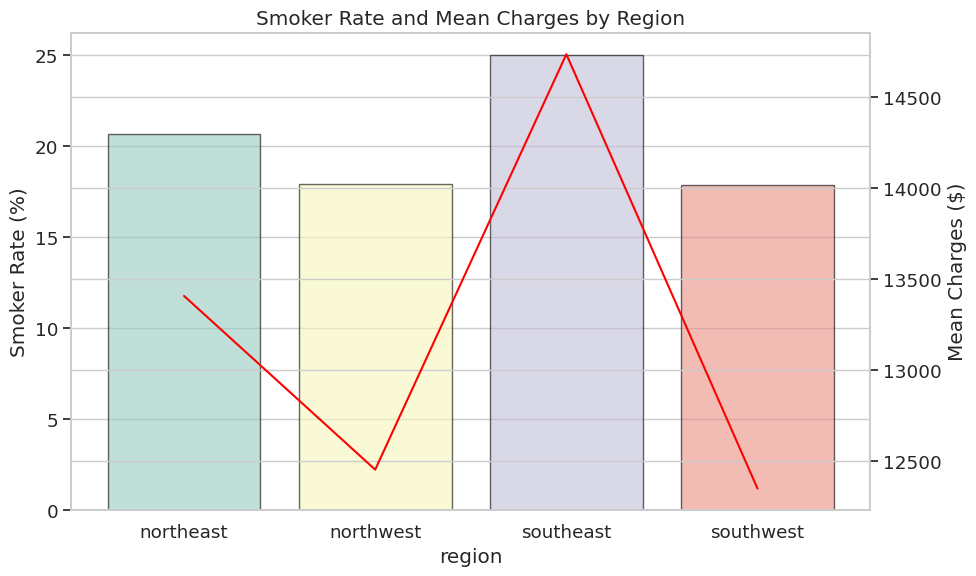

In [139]:
fig, ax1 =plt.subplots(figsize=(10,6))
sns.barplot(data=region_stats, x="region", y="smoker_rate", ax=ax1, color="lightblue", edgecolor="black",alpha=0.6,palette ="Set3")
ax2 =ax1.twinx()
sns.lineplot(data=region_stats, x="region", y="mean_charges", ax=ax2, color="red")

ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Mean Charges ($)")
plt.title("Smoker Rate and Mean Charges by Region")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [141]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_group', 'bmi_category'],
      dtype='object')

In [142]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("charges", axis=1), df["charges"], test_size=0.2, random_state=42)

In [143]:
# label encoding for categorical variables
categorical_features = ["sex", "smoker", "region", "bmi_category", "age_group"] 
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

    joblib.dump(le, f'../label_encoder_{col}.joblib')

In [144]:
label_encoders

{'sex': LabelEncoder(),
 'smoker': LabelEncoder(),
 'region': LabelEncoder(),
 'bmi_category': LabelEncoder(),
 'age_group': LabelEncoder()}

In [145]:
X_train

,age,sex,bmi,children,smoker,region,age_group,bmi_category
1114,23,1,24.5,0,0,0,0,0
968,21,1,25.7,2,0,0,0,2
599,52,0,37.5,2,0,1,3,1
170,63,1,41.5,0,0,2,4,1
275,47,0,26.6,2,0,0,3,2
...,...,...,...,...,...,...,...,...
1096,51,0,35.0,2,1,0,3,1
1131,27,1,45.9,2,0,3,1,1
1295,20,1,22.0,1,0,3,0,0
861,38,0,28.0,3,0,3,2,2


In [146]:
numeric_cols = ["age", "bmi", "children"]
scaler = StandardScaler()

In [147]:
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [148]:
joblib.dump(scaler, '../scaler.pkl')

['../scaler.pkl']

In [149]:
print(X_train.shape,y_train.shape)


(1069, 8) (1069,)


In [150]:
print(X_test.shape, y_test.shape)

(268, 8) (268,)


In [151]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [152]:
def evaluate_model(model,X_train, y_train, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 =r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2":r2,"MAE": mae,"RMSE": rmse}

In [153]:
results ={}

In [154]:
lr = LinearRegression()
lr.fit(X_train,y_train)
results["Linear Regression"] = evaluate_model(lr,X_train, y_train, X_test, y_test)
print("Linear Regresssion trained.")

best_poly_model = None
best_poly_score = -np.inf

for degree in [2, 3]:
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    score = poly_model.score(X_test_poly, y_test)

    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly_features, poly_model)

degree, poly_features, poly_model = best_poly_model

X_train_poly = poly_features.transform(X_train)
X_test_poly = poly_features.transform(X_test)

results[f"Polynomial Regression (degree={degree})"] = evaluate_model(
    poly_model,
    X_train_poly,
    y_train,
    X_test_poly,
    y_test
)

print(f"Polynomial Regression (degree={degree}) trained.")

Linear Regresssion trained.
Polynomial Regression (degree=2) trained.


In [155]:
# Train Random Forest Regressor

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
grid_rf = GridSearchCV(rf, rf_params, cv=5, n_jobs=-1, scoring='r2')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
results["Random Forest Regressor"] = evaluate_model(best_rf, X_train, y_train, X_test, y_test)
print("Random Forest Regressor trained,best parameters:", grid_rf.best_params_)


Random Forest Regressor trained,best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [156]:
results["Random Forest Regressor"]

{'R2': 0.8936614954059365,
 'MAE': 2436.619526885197,
 'RMSE': np.float64(4420.446251253538)}

In [157]:
# Train SVR model
svr = SVR()
svr_params = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2, 3]
}
grid_svr = GridSearchCV(svr, svr_params, cv=5, n_jobs=-1, scoring='r2')
grid_svr.fit(X_train, y_train)
best_svr = grid_svr.best_estimator_
results["SVR"] = evaluate_model(best_svr, X_train, y_train, X_test, y_test)
print("SVR trained,best parameters:",grid_svr.best_params_)

SVR trained,best parameters: {'C': 10, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}


In [158]:
# Train XGBoost model

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]
}
grid_xgb = GridSearchCV(xgb, xgb_params, cv=5, n_jobs=-1, scoring='r2')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
results["XGBoost"] = evaluate_model(best_xgb, X_train, y_train, X_test, y_test)
print("XGBoost trained,best parameters:",grid_xgb.best_params_)

XGBoost trained,best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [159]:
results

{'Linear Regression': {'R2': 0.8058869505499853,
  'MAE': 4201.456271235984,
  'RMSE': np.float64(5972.390639095035)},
 'Polynomial Regression (degree=2)': {'R2': 0.8886689655208406,
  'MAE': 2758.897190376896,
  'RMSE': np.float64(4523.024729261853)},
 'Random Forest Regressor': {'R2': 0.8936614954059365,
  'MAE': 2436.619526885197,
  'RMSE': np.float64(4420.446251253538)},
 'SVR': {'R2': -0.031629055991310606,
  'MAE': 7035.138881896395,
  'RMSE': np.float64(13768.372993182535)},
 'XGBoost': {'R2': 0.8990291478368355,
  'MAE': 2537.996938879344,
  'RMSE': np.float64(4307.436172060919)}}

In [162]:
result_df = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)
result_df

,R2,MAE,RMSE
XGBoost,0.90,2538.00,4307.44
Random Forest Regressor,0.89,2436.62,4420.45
Polynomial Regression (degree=2),0.89,2758.90,4523.02
Linear Regression,0.81,4201.46,5972.39
SVR,-0.03,7035.14,13768.37


In [163]:
# Save the best model
best_model_name = result_df.index[0]
if best_model_name == "Linear Regression":
    best_model = lr
elif "Polynomial Regression" in best_model_name:
    best_model = poly_model
elif best_model_name == "Random Forest Regressor":
    best_model = best_rf
elif best_model_name == "SVR":
    best_model = best_svr
elif best_model_name == "XGBoost":
    best_model = best_xgb
joblib.dump(best_model, '../best_model.pkl')

['../best_model.pkl']